In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
file_path = r"C:\Users\sudam\OneDrive\Documents\GGC\Data intensive 3170\Homework\Meteorite-landings\Meteorite_Landings.csv"

df = pd.read_csv(file_path)

print(df.head())


       name   id nametype     recclass  mass (g)  fall    year    reclat  \
0    Aachen    1    Valid           L5      21.0  Fell  1880.0  50.77500   
1    Aarhus    2    Valid           H6     720.0  Fell  1951.0  56.18333   
2      Abee    6    Valid          EH4  107000.0  Fell  1952.0  54.21667   
3  Acapulco   10    Valid  Acapulcoite    1914.0  Fell  1976.0  16.88333   
4   Achiras  370    Valid           L6     780.0  Fell  1902.0 -33.16667   

     reclong           GeoLocation  
0    6.08333     (50.775, 6.08333)  
1   10.23333  (56.18333, 10.23333)  
2 -113.00000    (54.21667, -113.0)  
3  -99.90000     (16.88333, -99.9)  
4  -64.95000   (-33.16667, -64.95)  


In [5]:
df = df.rename(columns={"mass (g)": "mass_g"})

In [6]:
df["mass_g"] = pd.to_numeric(df["mass_g"], errors="coerce")
df["reclat"] = pd.to_numeric(df["reclat"], errors="coerce")
df["reclong"] = pd.to_numeric(df["reclong"], errors="coerce")


In [7]:
df = df.dropna(subset=["reclat", "reclong"])

In [15]:
df["iron_level"] = df["recclass"].str.contains(
    "iron|H", case=False, na=False
)

df["iron_level"] = df["iron_level"].map({
    True: "High Iron",
    False: "Not High Iron"
})


In [16]:
iron_counts = df["iron_level"].value_counts()
print(iron_counts)

iron_level
Not High Iron    21010
High Iron        17391
Name: count, dtype: int64


In [18]:
import numpy as np

df["iron_group"] = np.select(
    [
        df["recclass"].str.contains("LL", case=False, na=False),
        df["recclass"].str.contains(r"\bL\b", case=False, na=False) & 
        ~df["recclass"].str.contains("LL", case=False, na=False),
        df["recclass"].str.contains("H|iron", case=False, na=False)
    ],
    [
        "Very Low",
        "Low",
        "High"
    ],
    default="Other"
)

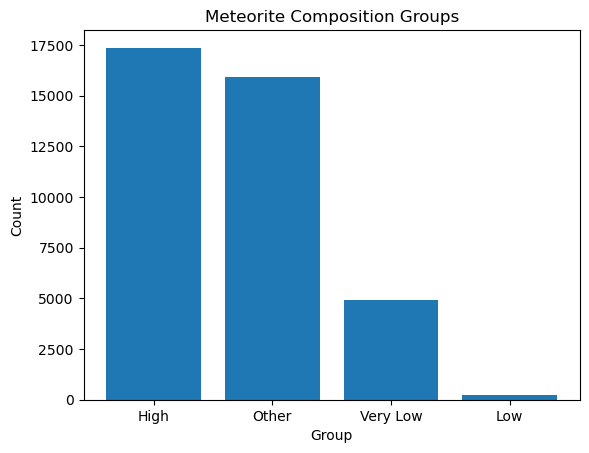

In [19]:
counts = df["iron_group"].value_counts()

plt.figure()

plt.bar(counts.index, counts.values)

plt.title("Meteorite Composition Groups")
plt.xlabel("Group")
plt.ylabel("Count")

plt.show()

In [20]:
order = ["Very Low", "Low", "High", "Other"]
counts = df["iron_group"].value_counts().reindex(order).fillna(0)

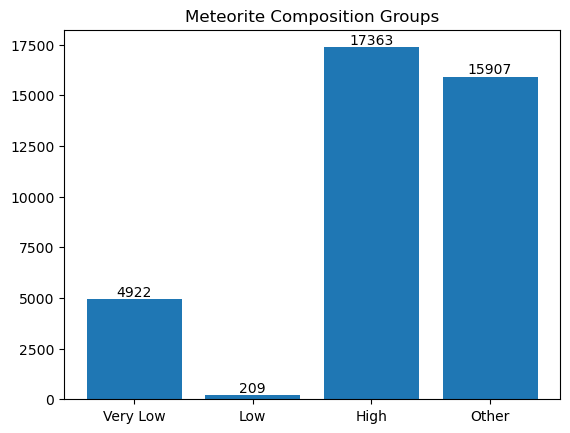

In [21]:
plt.bar(counts.index, counts.values)

for i, v in enumerate(counts.values):
    plt.text(i, v, str(int(v)), ha='center', va='bottom')

plt.title("Meteorite Composition Groups")
plt.show()

<Axes: xlabel='iron_group'>

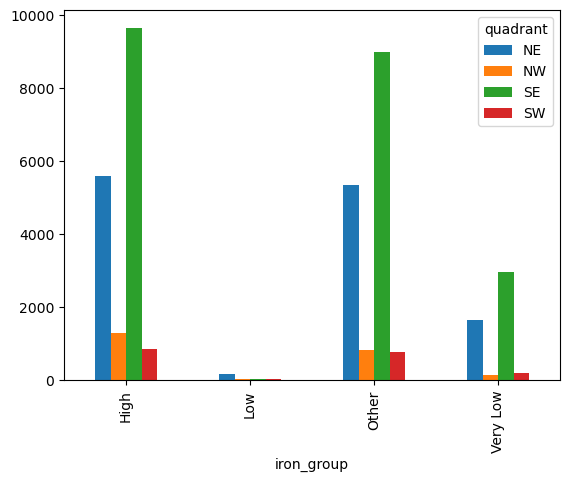

In [22]:
df.groupby(["iron_group", "quadrant"]).size().unstack().plot(kind="bar")

In [10]:
def get_quadrant(row):
    if row["reclat"] >= 0 and row["reclong"] >= 0:
        return "NE"
    elif row["reclat"] >= 0 and row["reclong"] < 0:
        return "NW"
    elif row["reclat"] < 0 and row["reclong"] >= 0:
        return "SE"
    else:
        return "SW"

df["quadrant"] = df.apply(get_quadrant, axis=1)

In [11]:
quadrant_counts = df["quadrant"].value_counts()
print(quadrant_counts)

quadrant
SE    21590
NE    12759
NW     2229
SW     1823
Name: count, dtype: int64


In [12]:
avg_mass = df.groupby("quadrant")["mass_g"].mean()
print(avg_mass)

quadrant
NE      9697.498267
NW    104550.505038
SE      7515.459722
SW     44061.866895
Name: mass_g, dtype: float64


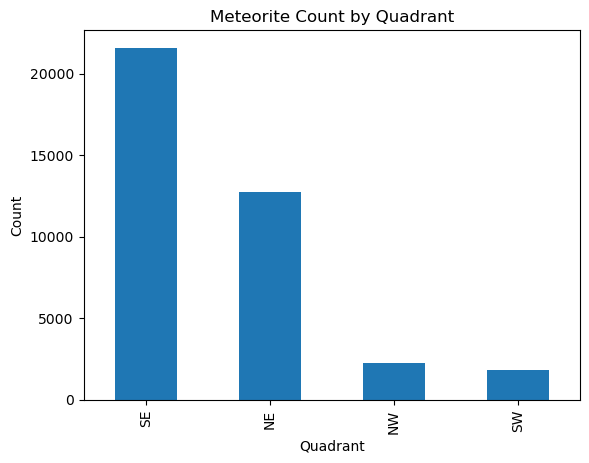

In [13]:
quadrant_counts.plot(kind="bar")
plt.title("Meteorite Count by Quadrant")
plt.xlabel("Quadrant")
plt.ylabel("Count")
plt.show()

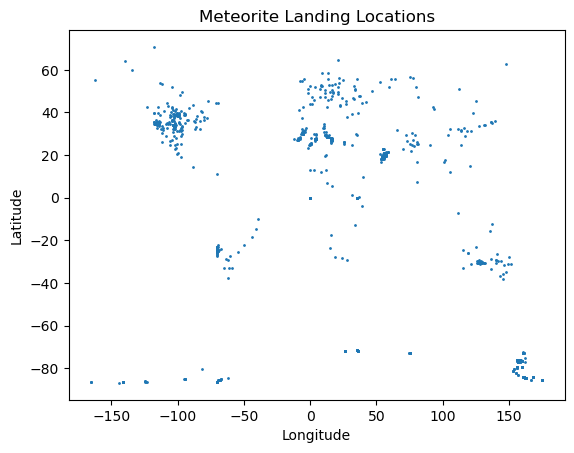

In [14]:
sample_df = df.sample(frac=0.1, random_state=42)

plt.scatter(sample_df["reclong"], sample_df["reclat"], s=1)
plt.title("Meteorite Landing Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()